# **Import Library**

In [ ]:
import kagglehub
import pandas as pd
import numpy as np
import re
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    roc_auc_score,
    roc_curve,
)
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from collections import Counter

# **Menentukan Device untuk Training**

In [ ]:
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f" Device yang digunakan : {device}")
print(f" PyTorch versi         : {torch.__version__}")

 Device yang digunakan : cpu
 PyTorch versi         : 2.10.0+cpu


# **Load Dataset**

In [ ]:
path = kagglehub.dataset_download("abdallahwagih/spam-emails")
df   = pd.read_csv(f"{path}/spam.csv", encoding="latin-1")

# Ambil hanya kolom yang relevan
df = df[["Category", "Message"]].dropna()
df.columns = ["label", "text"]

# Encode label: spam = 1, ham = 0
df["label"] = (df["label"].str.strip().str.lower() == "spam").astype(int)

print("=" * 45)
print(f"  Total sampel : {len(df):,}")
print(f"  Spam         : {df['label'].sum():,} ({df['label'].mean()*100:.1f}%)")
print(f"  Ham          : {(df['label']==0).sum():,} ({(df['label']==0).mean()*100:.1f}%)")
print("=" * 45)
df.head(5)

Using Colab cache for faster access to the 'spam-emails' dataset.
  Total sampel : 5,572
  Spam         : 747 (13.4%)
  Ham          : 4,825 (86.6%)


,label,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


# **EDA**

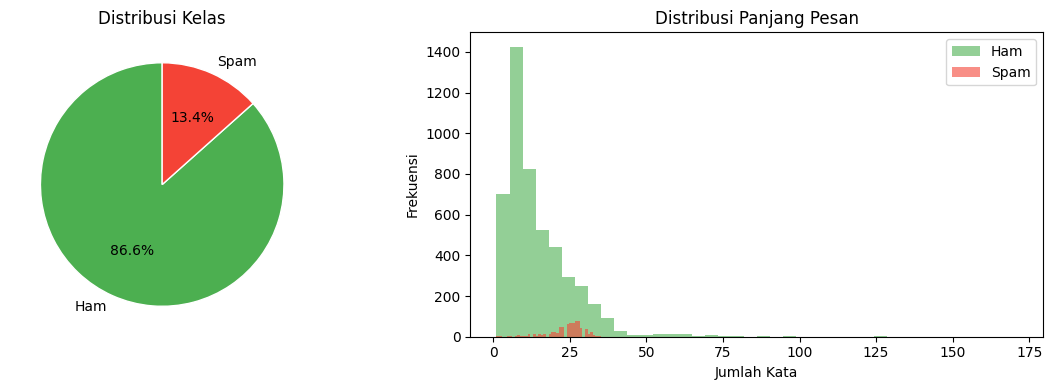

In [ ]:
# Hitung panjang teks
df["text_len"] = df["text"].apply(lambda x: len(str(x).split()))

# Buat figure
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# =====================================
# Pie Chart Distribusi Class
# =====================================
counts = df["label"].value_counts().sort_index()

axes[0].pie(
    counts,
    labels=["Ham", "Spam"],
    autopct="%1.1f%%",
    colors=["#4CAF50", "#F44336"],
    startangle=90,
    wedgeprops={"edgecolor": "white"}
)

axes[0].set_title("Distribusi Kelas")

# =====================================
# Histogram Panjang Pesan
# =====================================
for lbl, color, name in [(0, "#4CAF50", "Ham"), (1, "#F44336", "Spam")]:
    axes[1].hist(
        df[df["label"] == lbl]["text_len"],
        bins=40,
        alpha=0.6,
        color=color,
        label=name
    )

axes[1].set_title("Distribusi Panjang Pesan")
axes[1].set_xlabel("Jumlah Kata")
axes[1].set_ylabel("Frekuensi")
axes[1].legend()

plt.tight_layout()
plt.show()

# **Text Preprocessing**

In [ ]:
import re

def clean_text(text):
    text = str(text).lower()

    # hapus url
    text = re.sub(r"http\S+|www\S+", "", text)

    # hapus angka (opsional)
    text = re.sub(r"\d+", "", text)

    # hapus karakter selain huruf
    text = re.sub(r"[^a-z\s]", "", text)

    # hapus spasi berlebih
    text = re.sub(r"\s+", " ", text).strip()

    return text

df["text"] = df["text"].apply(clean_text)

# Contoh hasil preprocessing
print("Contoh hasil preprocessing:\n")
for i in [0, 1, 100]:
    print(f"  [{i}] Label : {'Spam' if df['label'].iloc[i] else 'Ham'}")
    print(f"       Teks  : {df['text'].iloc[i][:80]}...")
    print()


Contoh hasil preprocessing:

  [0] Label : Ham
       Teks  : go until jurong point crazy available only in bugis n great world la e buffet ci...

  [1] Label : Ham
       Teks  : ok lar joking wif u oni...

  [100] Label : Ham
       Teks  : please dont text me anymore i have nothing else to say...



#Membangun Vocabulary

## Vocabulary adalah kamus pemetaan kata → indeks integer.
## - `<PAD>` (indeks 0) : token padding untuk menyamakan panjang urutan
## - `<UNK>` (indeks 1) : token untuk kata yang tidak ada di vocabulary

In [ ]:
PAD_TOKEN = "<PAD>"
UNK_TOKEN = "<UNK>"
MAX_VOCAB  = 10_000   # maksimum jumlah kata unik
MAX_LEN    = 100      # maksimum panjang urutan per email

def build_vocab(texts: list, max_vocab: int = MAX_VOCAB) -> dict:
    """Membuat vocabulary dari kumpulan teks."""
    counter = Counter(word for text in texts for word in text.split())
    vocab = {PAD_TOKEN: 0, UNK_TOKEN: 1}
    for word, _ in counter.most_common(max_vocab - 2):
        vocab[word] = len(vocab)
    return vocab

vocab = build_vocab(df["text"].tolist())

print(f" Ukuran vocabulary : {len(vocab):,} kata")
print(f"   Contoh entri     : { {k: vocab[k] for k in list(vocab)[:6]} }")


 Ukuran vocabulary : 8,569 kata
   Contoh entri     : {'<PAD>': 0, '<UNK>': 1, 'i': 2, 'to': 3, 'you': 4, 'a': 5}


# **Encoding & Dataset**

In [ ]:
def encode_text(text: str, vocab: dict, max_len: int = MAX_LEN) -> list:
    """Mengubah teks menjadi list indeks integer."""
    tokens = text.split()[:max_len]
    return [vocab.get(token, 1) for token in tokens]   # 1 = UNK

In [ ]:
class SpamDataset(Dataset):
    """PyTorch Dataset untuk email spam/ham."""

    def __init__(self, texts: list, labels: list):
        self.X = [
            torch.tensor(encode_text(t, vocab), dtype=torch.long)
            for t in texts
        ]
        self.y = torch.tensor(labels, dtype=torch.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


In [ ]:
def collate_fn(batch):
    """Padding sequences agar panjangnya sama dalam satu batch."""
    sequences, labels = zip(*batch)
    padded = pad_sequence(sequences, batch_first=True, padding_value=0)
    return padded, torch.stack(labels)


In [ ]:
# Split data: 80% train, 20% test (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    df["text"].tolist(),
    df["label"].tolist(),
    test_size=0.2,
    random_state=SEED,
    stratify=df["label"],
)

In [ ]:
BATCH_SIZE = 64
train_loader = DataLoader(
    SpamDataset(X_train, y_train),
    batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn
)
test_loader = DataLoader(
    SpamDataset(X_test, y_test),
    batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn
)

print(f"Data train : {len(X_train):,} sampel  ({len(train_loader)} batch)")
print(f"Data test  : {len(X_test):,} sampel  ({len(test_loader)} batch)")

Data train : 4,457 sampel  (70 batch)
Data test  : 1,115 sampel  (18 batch)


In [ ]:
# Cek bentuk satu batch
sample_X, sample_y = next(iter(train_loader))
print(f"Shape satu batch input  : {tuple(sample_X.shape)}  (batch, seq_len)")
print(f"Shape satu batch label  : {tuple(sample_y.shape)}")

Shape satu batch input  : (64, 40)  (batch, seq_len)
Shape satu batch label  : (64,)


# **Arsitektur** Model RNN


# ------------------------------------------------------
#  Input (token ids)
#       │
#  ┌────▼─────┐
#  │ Embedding │  vocab_size → embed_dim (128)
#  └────┬─────┘
#       │
#  ┌────▼─────┐
#  │  Dropout  │  regularisasi (p=0.3)
#  └────┬─────┘
#       │
#  ┌────▼──────────────┐
#  │  Vanilla RNN       │  embed_dim → hidden_dim (256), 2 layers
#  │  (tanh activation) │
#  └────┬──────────────┘
#       │  ambil hidden state terakhir
#  ┌────▼─────┐
#  │  Dropout  │
#  └────┬─────┘
#       │
#  ┌────▼───────────┐
#  │ Linear (256→1) │  output logit
#  └────▼───────────┘
#  Sigmoid → probabilitas spam
# -----------------------------------------------------


In [ ]:
class VanillaRNN(nn.Module):
    """
    Klasifikasi teks menggunakan Vanilla RNN.

    Parameter
    ---------
    vocab_size  : jumlah kata unik dalam vocabulary
    embed_dim   : dimensi embedding layer
    hidden_dim  : jumlah unit tersembunyi di RNN
    n_layers    : jumlah layer RNN yang ditumpuk
    dropout     : probabilitas dropout untuk regularisasi
    """

    def __init__(
        self,
        vocab_size: int,
        embed_dim: int  = 128,
        hidden_dim: int = 256,
        n_layers: int   = 2,
        dropout: float  = 0.3,
    ):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)

        self.rnn = nn.RNN(
            input_size  = embed_dim,
            hidden_size = hidden_dim,
            num_layers  = n_layers,
            batch_first = True,
            dropout     = dropout if n_layers > 1 else 0.0,
            nonlinearity= "tanh",      # aktivasi default RNN
        )

        self.dropout = nn.Dropout(dropout)
        self.fc      = nn.Linear(hidden_dim, 1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (batch, seq_len)
        emb = self.dropout(self.embedding(x))      # (batch, seq_len, embed_dim)
        _, hidden = self.rnn(emb)                  # hidden: (n_layers, batch, hidden_dim)
        last_hidden = self.dropout(hidden[-1])     # ambil layer terakhir → (batch, hidden_dim)
        logits = self.fc(last_hidden).squeeze(1)   # (batch,)
        return logits


In [ ]:
#panggil model
model = VanillaRNN(vocab_size=len(vocab)).to(device)

In [ ]:
# Ringkasan parameter
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f"\n Total parameter yang bisa dilatih: {total_params:,}")


VanillaRNN(
  (embedding): Embedding(8569, 128, padding_idx=0)
  (rnn): RNN(128, 256, num_layers=2, batch_first=True, dropout=0.3)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=256, out_features=1, bias=True)
)

 Total parameter yang bisa dilatih: 1,327,489


# **Config Training**

In [ ]:
EPOCHS    = 15
LR        = 1e-3

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

# **Training Loop**

In [ ]:
def train_one_epoch(model, loader, optimizer, criterion):
    """Satu epoch training, kembalikan rata-rata loss."""
    model.train()
    total_loss = 0.0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        logits = model(X_batch)
        loss   = criterion(logits, y_batch)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # gradient clipping
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)


In [ ]:
@torch.no_grad()
def evaluate(model, loader):
    """Evaluasi model, kembalikan loss, akurasi, prediksi, probabilitas, dan label asli."""
    model.eval()
    total_loss = 0.0
    all_preds, all_probs, all_trues = [], [], []

    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        logits = model(X_batch)
        loss   = criterion(logits, y_batch)
        total_loss += loss.item()

        probs = torch.sigmoid(logits).cpu().numpy()
        preds = (probs > 0.5).astype(int)
        all_probs.extend(probs.tolist())
        all_preds.extend(preds.tolist())
        all_trues.extend(y_batch.cpu().int().tolist())

    avg_loss = total_loss / len(loader)
    accuracy = accuracy_score(all_trues, all_preds)
    return avg_loss, accuracy, all_preds, all_probs, all_trues


In [ ]:
# ── Training ──────────────────────────────────────────────────────────────────
history = {"train_loss": [], "val_loss": [], "val_acc": []}

print(f"{'Epoch':>6} | {'Train Loss':>10} | {'Val Loss':>8} | {'Val Acc':>8} | {'LR':>8}")
print("-" * 55)

best_acc = 0.0
best_state = None

for epoch in range(1, EPOCHS + 1):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion)
    val_loss, val_acc, _, _, _ = evaluate(model, test_loader)
    scheduler.step()

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    # Simpan model terbaik
    if val_acc > best_acc:
        best_acc   = val_acc
        best_state = {k: v.clone() for k, v in model.state_dict().items()}

    current_lr = optimizer.param_groups[0]["lr"]
    print(f"{epoch:>6} | {train_loss:>10.4f} | {val_loss:>8.4f} | {val_acc:>7.2%} | {current_lr:>8.6f}")

print(f"\n Best Validation Accuracy: {best_acc:.2%}")

 Epoch | Train Loss | Val Loss |  Val Acc |       LR
-------------------------------------------------------
     1 |     0.4110 |   0.3958 |  86.64% | 0.001000
     2 |     0.4008 |   0.4076 |  86.64% | 0.001000
     3 |     0.4108 |   0.6197 |  60.18% | 0.001000
     4 |     0.4455 |   0.3975 |  86.37% | 0.001000
     5 |     0.4215 |   0.3988 |  86.37% | 0.000500
     6 |     0.4110 |   0.3977 |  86.55% | 0.000500
     7 |     0.4106 |   0.4007 |  86.46% | 0.000500
     8 |     0.4105 |   0.3968 |  86.55% | 0.000500
     9 |     0.4048 |   0.3974 |  86.55% | 0.000500
    10 |     0.4058 |   0.3970 |  86.55% | 0.000250
    11 |     0.4038 |   0.3949 |  86.55% | 0.000250
    12 |     0.4010 |   0.3963 |  86.55% | 0.000250
    13 |     0.4006 |   0.3963 |  86.64% | 0.000250
    14 |     0.4004 |   0.3959 |  86.64% | 0.000250
    15 |     0.4004 |   0.3968 |  86.55% | 0.000125

 Best Validation Accuracy: 86.64%


In [ ]:
# Load bobot terbaik
model.load_state_dict(best_state)
print("Model terbaik berhasil dimuat kembali.")

Model terbaik berhasil dimuat kembali.


Training History

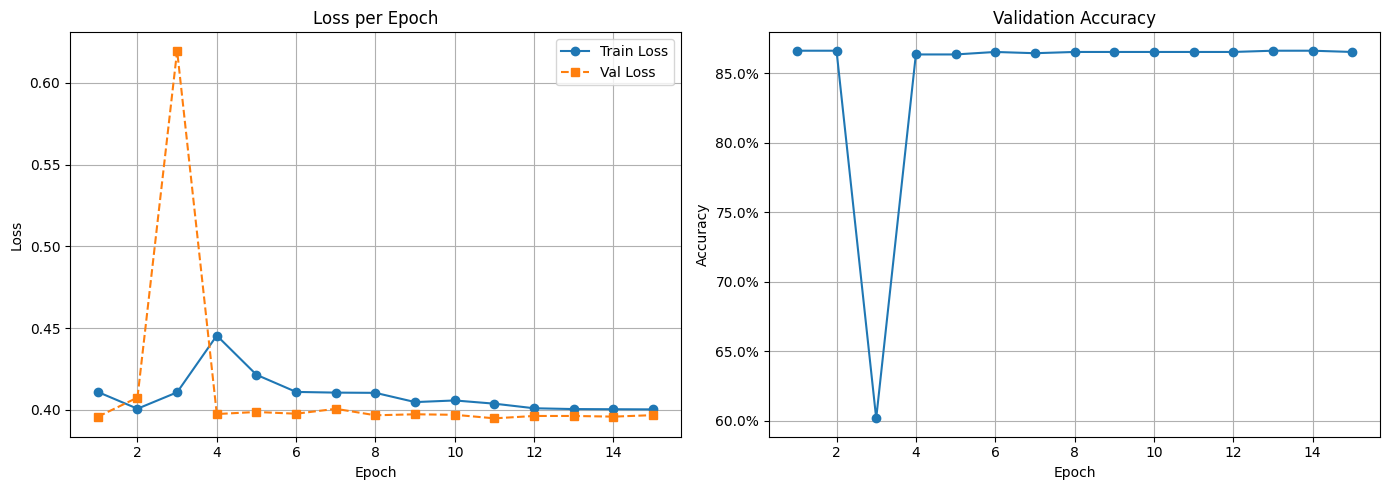

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

epochs_range = range(1, EPOCHS + 1)

# Buat subplot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ======================================
# Loss Curve
# ======================================
axes[0].plot(
    epochs_range,
    history["train_loss"],
    "o-",
    label="Train Loss"
)

axes[0].plot(
    epochs_range,
    history["val_loss"],
    "s--",
    label="Val Loss"
)

axes[0].set_title("Loss per Epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True)

# ======================================
# Accuracy Curve
# ======================================
axes[1].plot(
    epochs_range,
    history["val_acc"],
    "o-"
)

axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

axes[1].set_title("Validation Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].grid(True)

plt.tight_layout()
plt.show()

Evaluasi Model
#
# Metrik yang digunakan:
# - **Accuracy** : proporsi prediksi benar secara keseluruhan
# - **Precision** : dari semua yang diprediksi spam, berapa yang benar spam
# - **Recall** : dari semua spam asli, berapa yang berhasil terdeteksi
# - **F1-Score** : harmonic mean dari precision & recall
# - **ROC-AUC** : kemampuan model memisahkan kedua kelas

In [ ]:
_, final_acc, final_preds, final_probs, final_trues = evaluate(model, test_loader)

print("=" * 55)
print("         EVALUASI AKHIR MODEL RNN")
print("=" * 55)
print(classification_report(
    final_trues, final_preds,
    target_names=["Ham (0)", "Spam (1)"],
    digits=4
))
print(f"  Accuracy : {final_acc:.4f}  ({final_acc*100:.2f}%)")
print(f"  ROC-AUC  : {roc_auc_score(final_trues, final_probs):.4f}")
print("=" * 55)


         EVALUASI AKHIR MODEL RNN
              precision    recall  f1-score   support

     Ham (0)     0.8664    1.0000    0.9284       966
    Spam (1)     0.0000    0.0000    0.0000       149

    accuracy                         0.8664      1115
   macro avg     0.4332    0.5000    0.4642      1115
weighted avg     0.7506    0.8664    0.8043      1115

  Accuracy : 0.8664  (86.64%)
  ROC-AUC  : 0.4641


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


[[966   0]
 [149   0]]


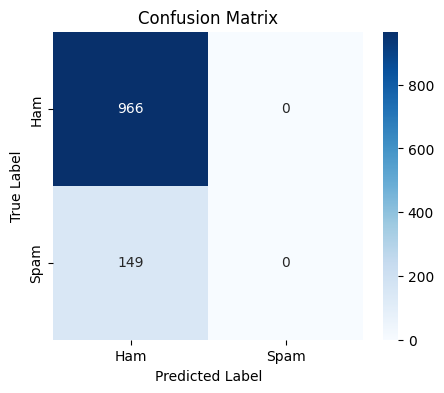

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix

# Generate confusion matrix
cm = confusion_matrix(final_trues, final_preds)

print(cm)

# Plot
plt.figure(figsize=(5, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Ham", "Spam"],
    yticklabels=["Ham", "Spam"]
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

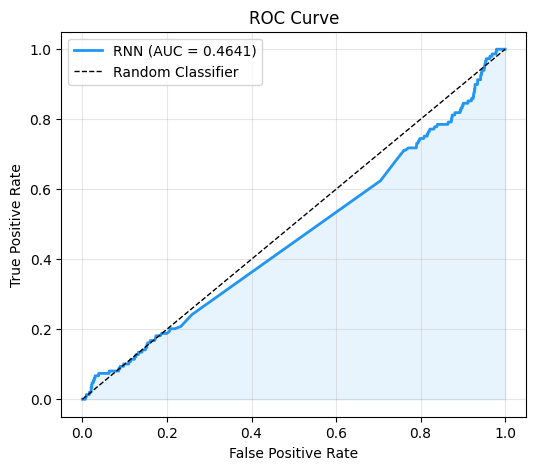

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# Hitung ROC
fpr, tpr, _ = roc_curve(final_trues, final_probs)
auc_score = roc_auc_score(final_trues, final_probs)

# Plot ROC
plt.figure(figsize=(6, 5))

plt.plot(
    fpr,
    tpr,
    lw=2,
    color="#2196F3",
    label=f"RNN (AUC = {auc_score:.4f})"
)

# Garis random classifier
plt.plot(
    [0, 1],
    [0, 1],
    "k--",
    lw=1,
    label="Random Classifier"
)

# Area bawah kurva
plt.fill_between(
    fpr,
    tpr,
    alpha=0.1,
    color="#2196F3"
)

plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

In [ ]:
#Simpan model
SAVE_PATH = "rnn_spam_classifier.pth"
torch.save({
    "model_state_dict": model.state_dict(),
    "vocab": vocab,
    "config": {
        "vocab_size": len(vocab),
        "embed_dim" : 128,
        "hidden_dim": 256,
        "n_layers"  : 2,
        "dropout"   : 0.3,
    },
    "best_accuracy": best_acc,
}, SAVE_PATH)
print(f" Model disimpan di: {SAVE_PATH}")

 Model disimpan di: rnn_spam_classifier.pth


In [ ]:

# Cara memuat kembali:
checkpoint = torch.load(SAVE_PATH, map_location=device)
model_loaded = VanillaRNN(**checkpoint["config"]).to(device)
model_loaded.load_state_dict(checkpoint["model_state_dict"])
vocab_loaded = checkpoint["vocab"]


In [ ]:
def predict_email(text: str, model: nn.Module, vocab: dict, threshold: float = 0.5):
    """
    Prediksi apakah sebuah email adalah Spam atau Ham.

    Parameter
    ---------
    text      : teks email mentah
    model     : model yang sudah dilatih
    vocab     : vocabulary yang digunakan saat training
    threshold : batas probabilitas untuk klasifikasi spam (default 0.5)

    Return
    ------
    label (str), confidence (float)
    """
    model.eval()
    cleaned = clean_text(text)
    tokens  = torch.tensor(encode_text(cleaned, vocab), dtype=torch.long)
    tokens  = tokens.unsqueeze(0).to(device)   # tambah dimensi batch

    with torch.no_grad():
        logit = model(tokens)
        prob  = torch.sigmoid(logit).item()

    label = "SPAM " if prob >= threshold else "HAM  "
    return label, prob


# ── Demo Inferensi ────────────────────────────────────────────────────────────
test_emails = [
    ("Spam",
     "WINNER!! Claim your FREE iPhone now! Click the link: bit.ly/win-now. "
     "Limited time offer. Reply with your bank details to receive prize money!"),

    ("Ham",
     "Hi Sarah, just checking if we're still on for the team meeting tomorrow at 2pm. "
     "Let me know if you need to reschedule. Thanks!"),

    ("Spam",
     "URGENT: Your account will be suspended! Verify your identity immediately "
     "by calling 0800-FREE or visiting our site. Act NOW!"),

    ("Ham",
     "Hey, can you pick up some groceries on the way home? "
     "We need milk, eggs, and bread. See you tonight!"),

    ("Spam",
     "Congratulations! You've been selected for a £1000 cash reward. "
     "To claim, text WIN to 80808. Std msg charges may apply."),
]

print("=" * 65)
print(f"{'HASIL PREDIKSI EMAIL':^65}")
print("=" * 65)
print(f"{'No':<4} {'Label Asli':<12} {'Prediksi':<12} {'Confidence':>10}  {'Benar?':>6}")
print("-" * 65)

correct = 0
for i, (true_label, email_text) in enumerate(test_emails, 1):
    pred_label, confidence = predict_email(email_text, model, vocab)
    pred_str  = "Spam" if "SPAM" in pred_label else "Ham"
    is_correct = "✅" if pred_str == true_label else "❌"
    if pred_str == true_label:
        correct += 1
    print(f"{i:<4} {true_label:<12} {pred_label:<12} {confidence:>9.2%}  {is_correct:>6}")

print("-" * 65)
print(f"{'Akurasi Demo':>40}: {correct}/{len(test_emails)} ({correct/len(test_emails)*100:.0f}%)")
print("=" * 65)

                      HASIL PREDIKSI EMAIL                       
No   Label Asli   Prediksi     Confidence  Benar?
-----------------------------------------------------------------
1    Spam         HAM             10.02%       ❌
2    Ham          HAM             10.90%       ✅
3    Spam         HAM             12.58%       ❌
4    Ham          HAM              7.41%       ✅
5    Spam         HAM             13.18%       ❌
-----------------------------------------------------------------
                            Akurasi Demo: 2/5 (40%)
